In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

# TASK 1

In [2]:
data = load_breast_cancer()

In [3]:
print(data.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [4]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [5]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
print("Shape:", df.shape)

Shape: (569, 31)


In [7]:
print(df.columns)

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [9]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## Target distribution

In [14]:
print(df['target'].value_counts())

target
1    357
0    212
Name: count, dtype: int64


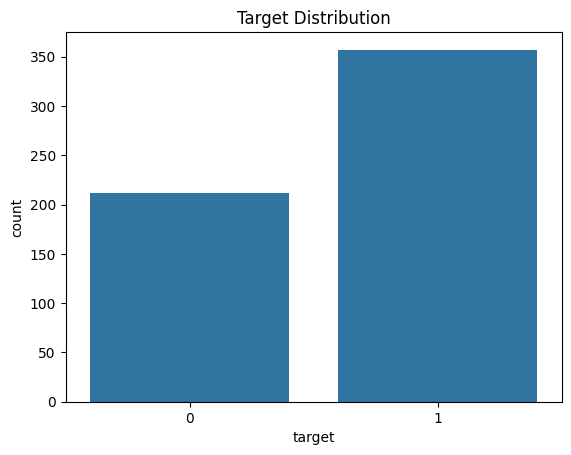

In [15]:
sns.countplot(x='target', data=df)
plt.title("Target Distribution")
plt.show()

## Feature Scaling
### Separate X and y:

In [16]:
X = df.drop('target', axis=1)
y = df['target']

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
print(X_scaled[:5])

[[ 1.09706398e+00 -2.07333501e+00  1.26993369e+00  9.84374905e-01
   1.56846633e+00  3.28351467e+00  2.65287398e+00  2.53247522e+00
   2.21751501e+00  2.25574689e+00  2.48973393e+00 -5.65265059e-01
   2.83303087e+00  2.48757756e+00 -2.14001647e-01  1.31686157e+00
   7.24026158e-01  6.60819941e-01  1.14875667e+00  9.07083081e-01
   1.88668963e+00 -1.35929347e+00  2.30360062e+00  2.00123749e+00
   1.30768627e+00  2.61666502e+00  2.10952635e+00  2.29607613e+00
   2.75062224e+00  1.93701461e+00]
 [ 1.82982061e+00 -3.53632408e-01  1.68595471e+00  1.90870825e+00
  -8.26962447e-01 -4.87071673e-01 -2.38458552e-02  5.48144156e-01
   1.39236330e-03 -8.68652457e-01  4.99254601e-01 -8.76243603e-01
   2.63326966e-01  7.42401948e-01 -6.05350847e-01 -6.92926270e-01
  -4.40780058e-01  2.60162067e-01 -8.05450380e-01 -9.94437403e-02
   1.80592744e+00 -3.69203222e-01  1.53512599e+00  1.89048899e+00
  -3.75611957e-01 -4.30444219e-01 -1.46748968e-01  1.08708430e+00
  -2.43889668e-01  2.81189987e-01]
 [ 1.5

# TASK 2

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [20]:
def evaluate_split(test_size):
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )
    
    # Scale after split
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Temporary K for Task 2
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_scaled, y_train)
    
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    
    return len(X_train), len(X_test), accuracy

In [21]:
splits = [0.2, 0.3, 0.1]

for split in splits:
    train_size, test_size, acc = evaluate_split(split)
    
    print(f"Split {(1-split)*100:.0f}:{split*100:.0f}")
    print(f"Training Samples: {train_size}")
    print(f"Testing Samples: {test_size}")
    print(f"Accuracy: {acc:.4f}")
    print()

Split 80:20
Training Samples: 455
Testing Samples: 114
Accuracy: 0.9561

Split 70:30
Training Samples: 398
Testing Samples: 171
Accuracy: 0.9591

Split 90:10
Training Samples: 512
Testing Samples: 57
Accuracy: 0.9825



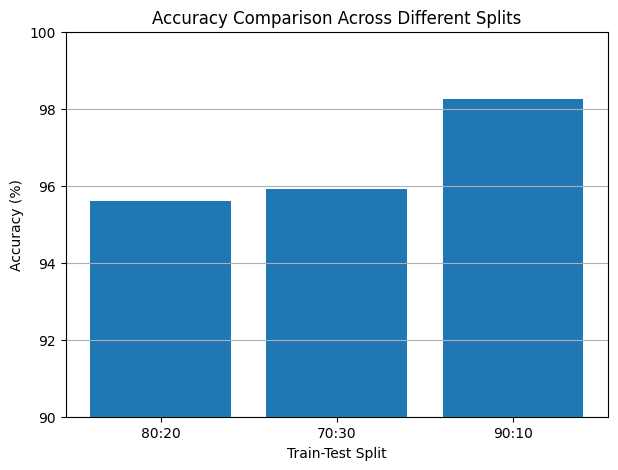

In [22]:
splits = ['80:20', '70:30', '90:10']
accuracies = [95.61, 95.91, 98.25]

plt.figure(figsize=(7,5))
plt.bar(splits, accuracies)
plt.xlabel("Train-Test Split")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison Across Different Splits")
plt.ylim(90, 100)
plt.grid(axis='y')
plt.show()

# TASK 3

## Model Training using heuristic K

### Prepare 80:20 split

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Evaluate multiple K values

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 31)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

### Plot Accuracy vs K

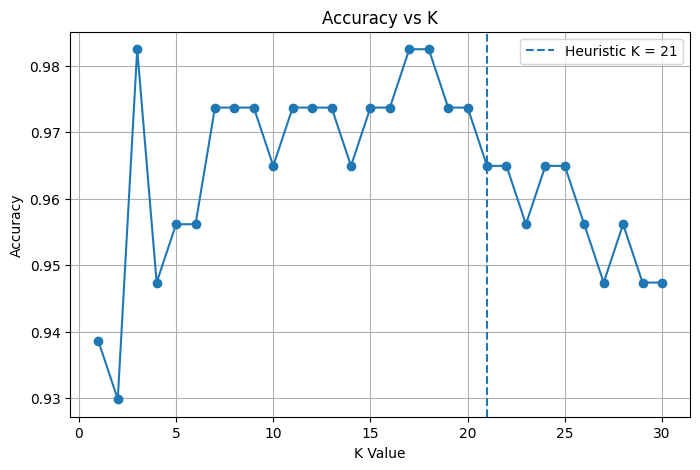

In [25]:
plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o')
plt.axvline(x=21, linestyle='--', label='Heuristic K = 21')

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.grid(True)
plt.legend()
plt.show()

### Best K

In [26]:
best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)

Best K: 3
Best Accuracy: 0.9824561403508771


# Part A — Distance Metrics

## 1) Euclidean Distance Formula

The Euclidean distance between two points $X$ and $Y$ in an $n$-dimensional space is defined as:

$$d(X, Y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

This represents the standard, straight-line distance between two points in a geometric space.



### Example Calculation

Let's calculate the distance between two 2D points, $X$ and $Y$:
* **Point X** $= (x_1, x_2) = (2, 3)$
* **Point Y** $= (y_1, y_2) = (5, 7)$

$$
\begin{aligned}
d(X, Y) &= \sqrt{(5 - 2)^2 + (7 - 3)^2} \\
&= \sqrt{(3)^2 + (4)^2} \\
&= \sqrt{9 + 16} \\
&= \sqrt{25} \\
&= 5
\end{aligned}
$$

### When is it suitable?

Use Euclidean distance when:
* **Continuous Features:** The data consists of continuous numerical values.
* **Properly Scaled Data:** The features are normalized or scaled (e.g., using Min-Max Scaling or Standard Scaling) so that features with larger magnitudes do not disproportionately dominate the distance calculation.
* **Geometric Meaning:** A straight-line spatial distance is logically or physically meaningful for the problem.

> **Application Note:** Since the breast cancer dataset consists of continuous, scaled numerical features (such as cell radius, perimeter, and texture), the Euclidean distance metric is highly suitable.

## 2) Manhattan Distance

### Formula
The Manhattan distance (also known as $L_1$ distance or city-block distance) between two points $X$ and $Y$ in an $n$-dimensional space is defined as:

$$d(X, Y) = \sum_{i=1}^{n} |x_i - y_i|$$

Instead of finding the straight-line diagonal, this metric calculates the distance if you were to travel strictly along orthogonal (grid-like) axes.



### Example Calculation
Let's calculate the distance between the same two 2D points, $X$ and $Y$:
* **Point X** $= (x_1, x_2) = (2, 3)$
* **Point Y** $= (y_1, y_2) = (5, 7)$

$$
\begin{aligned}
d(X, Y) &= |5 - 2| + |7 - 3| \\
&= |3| + |4| \\
&= 3 + 4 \\
&= 7
\end{aligned}
$$

### Why is it called "City-Block" distance?
Imagine navigating a city grid (like Manhattan, New York) where streets run strictly north-south and east-west. To get from one point to another, you cannot walk diagonally through buildings. You must move horizontally first, and then vertically along the streets. 

### When is it suitable?
Use Manhattan distance when:
* **High-Dimensional Data:** In very high-dimensional spaces, Manhattan distance often performs better and suffers less from the "curse of dimensionality" than Euclidean distance.
* **Robustness to Outliers:** Because it does not square the differences (unlike Euclidean), it does not heavily penalize large differences in a single feature. This makes it more robust to outliers.
* **Grid-Based Constraints:** The problem domain naturally restricts movement to a grid-like or chessboard-like pattern.

| Metric    | Formula       | Best For                                |
| --------- | ------------- | --------------------------------------- |
| Euclidean | Straight-line | Continuous scaled numerical data        |
| Manhattan | Grid distance | High-dimensional / outlier-robust tasks |


### Apply PCA

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [28]:
print(X_pca.shape)

(569, 2)


### Train-test split on PCA data

In [29]:
from sklearn.model_selection import train_test_split

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Function to plot decision boundary

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

def plot_decision_boundary(k):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_pca, y_train_pca)

    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7,5))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(
        X_train_pca[:, 0],
        X_train_pca[:, 1],
        c=y_train_pca,
        edgecolor='k',
        s=25
    )

    plt.title(f"Decision Boundary (K={k})")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.show()

### Plot for required K values

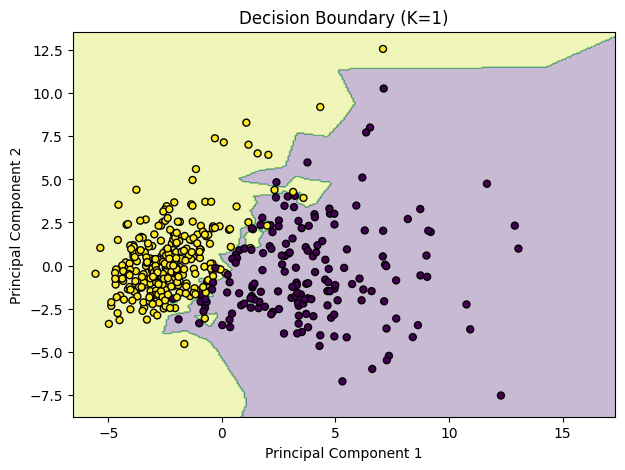

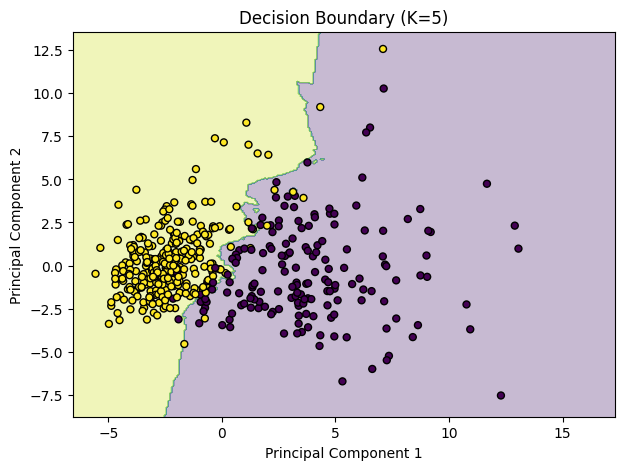

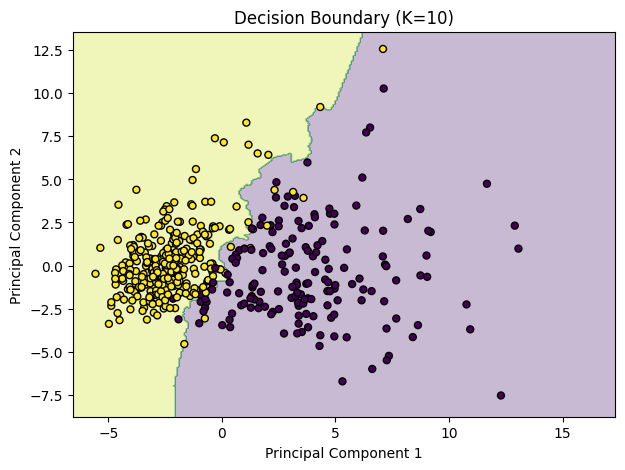

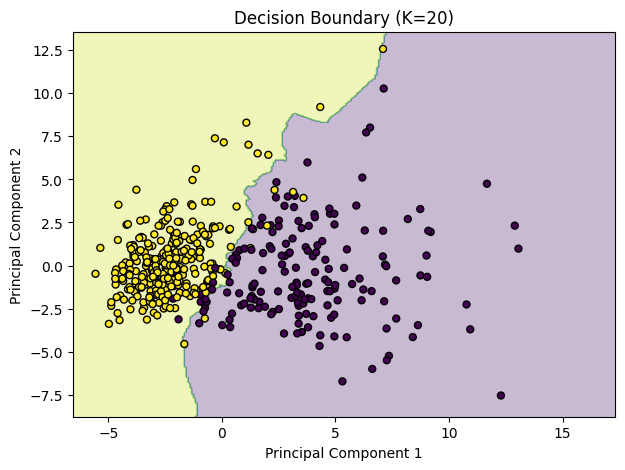

In [31]:
plot_decision_boundary(1)
plot_decision_boundary(5)
plot_decision_boundary(10)
plot_decision_boundary(20)

## 3) KNN Decision Boundary Analysis

### Impact of K-Value on Decision Boundaries

The value of $K$ in the K-Nearest Neighbors algorithm directly controls the balance between overfitting and underfitting by altering the shape of the decision boundary.

* **$K = 1$ (High Variance, Low Bias)**
  * **Boundary:** Very irregular, jagged, and complex.
  * **Characteristics:** Highly sensitive to noise and outliers.
  * **Risk:** **Overfitting.** The model essentially memorizes the training data points rather than learning the underlying distribution.

* **$K = 5$ (Optimal Balance)**
  * **Boundary:** Smoother and cleaner.
  * **Characteristics:** Less noisy, showing significantly better generalization capabilities. 
  * **Risk:** Usually strikes the ideal balance for prediction.

* **$K = 10$ (Stable Predictions)**
  * **Boundary:** Even smoother and more rounded.
  * **Characteristics:** More stable predictions as local fluctuations are averaged out across a larger neighborhood.

* **$K = 20$ (Low Variance, High Bias)**
  * **Boundary:** Exceptionally smooth and rigid.
  * **Characteristics:** Local data patterns and fine details are completely ignored.
  * **Risk:** **Underfitting.** The model becomes overly generalized and begins predicting based heavily on the majority class of the entire dataset.

---

### Summary of Experimental Results (PCA-Reduced Space)



To visually interpret these characteristics, a decision boundary analysis was performed after reducing the 30-dimensional breast cancer dataset down to **2 dimensions using Principal Component Analysis (PCA)**. 

The experimental observations strongly align with theoretical expectations:
* For **$K = 1$**, the decision boundary was highly irregular, catching isolated noise points and confirming an overfitted model.
* As $K$ was stepped up to **$K = 5$** and **$K = 10$**, the boundary smoothed out structurally, demonstrating strong generalization on unseen data.
* At **$K = 20$**, the boundary became excessively smooth and rigid, indicating the onset of underfitting where vital local malignant/benign data patterns were ignored.

> **Key Takeaway:** This experiment clearly demonstrates the bias-variance tradeoff in KNN. Increasing the value of $K$ reduces model variance (making it less sensitive to training data fluctuations) but increases its bias (making it less flexible to complex boundaries).

# TASK 4

In [32]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

### Cross-validation for different K

In [33]:
k_values = range(1, 31)
cv_scores = []

for k in k_values:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    
    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=5,
        scoring='accuracy'
    )
    
    cv_scores.append(scores.mean())

### Plot CV accuracy vs K

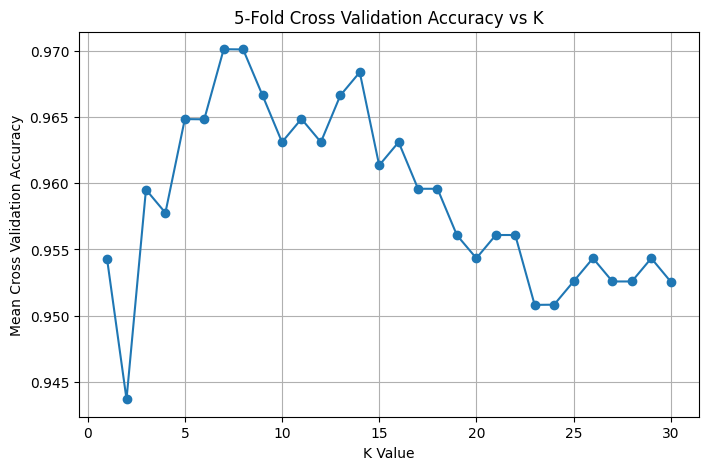

In [34]:
plt.figure(figsize=(8,5))
plt.plot(k_values, cv_scores, marker='o')

plt.xlabel("K Value")
plt.ylabel("Mean Cross Validation Accuracy")
plt.title("5-Fold Cross Validation Accuracy vs K")
plt.grid(True)
plt.show()

### Best K from Cross Validation

In [35]:
best_cv_k = k_values[np.argmax(cv_scores)]
best_cv_score = max(cv_scores)

print("Best K from CV:", best_cv_k)
print("Best Mean Accuracy:", best_cv_score)

Best K from CV: 7
Best Mean Accuracy: 0.9701288619779538


| Method                  | Best K | Accuracy |
| ----------------------- | -----: | -------: |
| Heuristic Rule          |     21 |   ~96.5% |
| Train-Test Split        |      3 |   98.25% |
| 5-Fold Cross Validation |      7 |   97.01% |


## 4) Model Evaluation: Train-Test Split vs. Cross-Validation

### Comparison of Results

| Method | Best $K$ | Performance / Characteristics |
| :--- | :--- | :--- |
| **Train-Test Split (80:20)** | $K = 3$ | **Accuracy:** $98.25\%$ (Highly optimistic, but split-dependent) |
| **5-Fold Cross-Validation** | $K = 7$ | **Robustness:** Highly reliable, accounts for data variance |

---

### The Limitations of a Single Train-Test Split
While a $K = 3$ yields an impressive $98.25\%$ accuracy on the 80:20 split, it is vital to remember that **this result depends entirely on that single random split**. 
* If the random state changes, the data points in the training and testing sets shift.
* A different split could easily shift the optimal neighborhood size to a different value.
* Therefore, relying purely on a single train-test split makes $K = 3$ a slightly optimistic or volatile choice.

---

### Why Cross-Validation ($K = 7$) is More Reliable
Cross-Validation (CV) provides a much safer estimate because the model is trained and evaluated across **5 different folds**. 



* **Reduces Randomness:** Each fold acts as an independent train-test split. The final metric is an average, ensuring that the performance isn't just a fluke of a "lucky" data split.
* **True Generalization:** It forces the model to perform consistently across different subsets of the entire dataset.

---

### Conceptual Question: Why did the optimal $K$ change from $3 \rightarrow 7$?

The shift from a smaller neighborhood ($K=3$) to a larger neighborhood ($K=7$) during Cross-Validation highlights a classic machine learning trade-off:

* **At $K = 3$ (Local Focus):** The model relies on very tight, localized neighborhoods. While this can capture highly specific, fine-grained patterns within a single split, it is inherently more prone to overfitting to local noise.
* **At $K = 7$ (Global Generalization):** By expanding the neighborhood to 7 neighbors, the decision boundary becomes smoother. It forces the algorithm to look at a broader consensus, making it less sensitive to random noise or outliers present in individual folds.

> **Conclusion:** Cross-Validation intentionally penalizes models that overfit to specific data pockets. Because it evaluates across multiple variations of the data, **CV naturally prefers a slightly larger $K$ (like $K=7$)** to ensure stable, well-generalized performance on unseen data.

# Predictions

In [36]:
from sklearn.neighbors import KNeighborsClassifier

final_knn = KNeighborsClassifier(n_neighbors=7)
final_knn.fit(X_train_scaled, y_train)

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [37]:
y_pred = final_knn.predict(X_test_scaled)

In [38]:
print(y_pred[:20])

[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1]


In [39]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Final Model Accuracy:", accuracy)

Final Model Accuracy: 0.9736842105263158


In [67]:
sample = X.iloc[[542]]
print(sample)

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
542        14.74         25.42            94.7      668.6          0.08275   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
542           0.07214         0.04105              0.03027          0.184   

     mean fractal dimension  ...  worst radius  worst texture  \
542                  0.0568  ...         16.51          32.29   

     worst perimeter  worst area  worst smoothness  worst compactness  \
542            107.4       826.4             0.106             0.1376   

     worst concavity  worst concave points  worst symmetry  \
542           0.1611                0.1095          0.2722   

     worst fractal dimension  
542                  0.06956  

[1 rows x 30 columns]


In [68]:
sample_scaled = scaler.transform(sample)

In [69]:
prediction = final_knn.predict(sample_scaled)
print(prediction)

[1]


In [70]:
if prediction[0] == 0:
    print("Predicted: Malignant")
else:
    print("Predicted: Benign")

Predicted: Benign


# TASK 5

### ROC Curve + AUC

### Train final model

In [76]:
from sklearn.neighbors import KNeighborsClassifier

final_knn = KNeighborsClassifier(n_neighbors=7)
final_knn.fit(X_train_scaled, y_train)

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Predict Test Data

In [77]:
y_pred = final_knn.predict(X_test_scaled)

### Accuracy

In [78]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9736842105263158


### Precision

In [79]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.96


### Recall

In [80]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 1.0


### F1 Score

In [81]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.9795918367346939


### Confusion Matrix

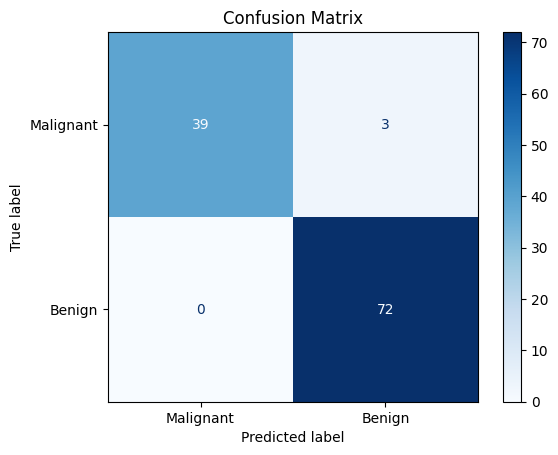

In [83]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant", "Benign"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

### Classification Report

In [84]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Malignant", "Benign"]
))

              precision    recall  f1-score   support

   Malignant       1.00      0.93      0.96        42
      Benign       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



### Classification Report

In [85]:
y_prob = final_knn.predict_proba(X_test_scaled)[:, 1]

In [86]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

AUC Score: 0.9884259259259259


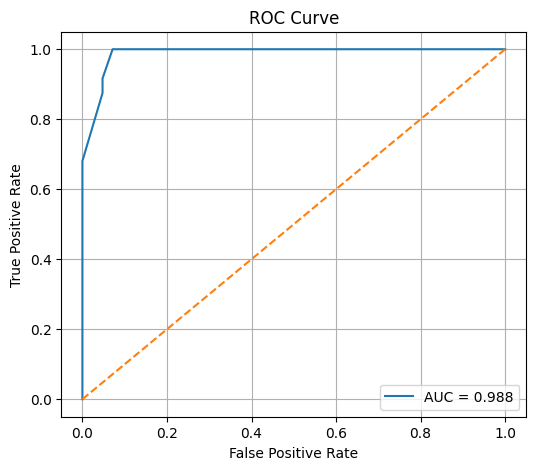

In [87]:
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# Task 6: Comparative Study with Regression (Lab 3 Integration)

## Comparison of Regression and Classification Metrics
Regression and classification use different evaluation metrics because their outputs are different. Regression predicts continuous numerical values, so metrics like **MAE, MSE, RMSE, and R²** are used to measure prediction error. Classification predicts categories or classes, so metrics like **Accuracy, Precision, Recall, F1 Score, and Confusion Matrix** are used to measure decision correctness.

---

## Error-Based Evaluation (Regression)
Regression evaluation is error-based because the predicted value can differ from the actual value by some amount. Metrics such as **MAE, MSE, and RMSE** measure how large this prediction error is.

**Example:**  
Actual GPA = 3.5  
Predicted GPA = 3.2  
Error = 0.3  

---

## Decision-Based Evaluation (Classification)
Classification evaluation is decision-based because the output is a class label. The prediction is either correct or incorrect. Metrics like **Accuracy, Precision, Recall, and F1 Score** evaluate how well the model classifies data.

**Example:**  
Actual = Malignant  
Predicted = Benign → Wrong classification  

---

## R² Score vs Accuracy
- **R² Score** measures how well a regression model explains variation in data. Higher R² means better prediction of numerical values.  
- **Accuracy** measures the percentage of correct classifications. Higher accuracy means better classification performance.

---

## RMSE vs F1 Score
- **RMSE** measures the average magnitude of prediction error in regression. Lower RMSE is better.  
- **F1 Score** balances precision and recall in classification. Higher F1 score indicates better overall classification performance.

---

## MAE vs Confusion Matrix
- **MAE** gives the average absolute error between actual and predicted numerical values.  
- **Confusion Matrix** shows the number of correct and incorrect classifications (**TP, TN, FP, FN**).

---

## Continuous Prediction vs Classification
- **Continuous Prediction Tasks (Regression):** Output is numerical, such as GPA, salary, or house price. Evaluation focuses on prediction error.  
- **Classification Tasks:** Output is categorical, such as benign/malignant or spam/not spam. Evaluation focuses on correct decision-making.

---

## Inference
Regression metrics measure **how far predictions are from actual values**, while classification metrics measure **how correctly the model makes decisions**. Regression focuses on error magnitude, whereas classification focuses on prediction correctness.

## Inference Requirement

Regression metrics such as **MAE, MSE, and RMSE** measure the magnitude of prediction error by calculating how far the predicted numerical values are from the actual values. Lower values indicate better regression performance. The **R² score** measures how well the regression model explains the variance in the data.

Classification metrics evaluate **decision correctness** rather than numerical error. Metrics such as **Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and ROC-AUC** measure how correctly the model classifies samples into their respective classes.

Accuracy alone is often insufficient in **medical diagnosis** because a model may achieve high accuracy simply by predicting the majority class while still missing critical disease cases. In cancer prediction, missing a malignant case can be dangerous and may delay treatment.

**Recall** is more important in healthcare because it measures how many actual positive cases are correctly identified. High recall ensures that disease cases are not missed. **ROC-AUC** is also important because it evaluates how well the model separates positive and negative classes across different classification thresholds.

Overall, regression and classification use different evaluation frameworks. Regression focuses on **prediction error magnitude for continuous outputs**, whereas classification focuses on **decision quality for categorical outputs**.

# Task 7: Analytical Questions

## 1. Why is KNN called a lazy learning algorithm?
KNN is called a lazy learning algorithm because it does not build a model during training. It simply stores the training data and performs computation only when a new data point needs to be classified.

---

## 2. Why is feature scaling required in KNN?
Feature scaling is required because KNN is a distance-based algorithm. Features with larger numerical values can dominate distance calculations and bias the prediction. Scaling ensures all features contribute equally.

---

## 3. Explain heuristic K selection using √n rule.
A common heuristic for choosing K is:

\[
K = \sqrt{n}
\]

where **n** is the number of training samples. This provides a reasonable starting value for K, which can later be optimized using validation methods.

---

## 4. Why is cross-validation more reliable than a single train-test split?
Cross-validation is more reliable because it evaluates the model on multiple train-test splits instead of just one. This reduces dependence on a single random split and provides a better estimate of model generalization.

---

## 5. How does K affect bias-variance trade-off?
Small K values lead to low bias but high variance, which may cause overfitting. Large K values lead to high bias but low variance, which may cause underfitting. Choosing the right K balances bias and variance.

---

## 6. Why is recall more important than accuracy in cancer prediction?
Recall is more important because it measures how many actual cancer cases are correctly identified. Missing a cancer case (false negative) can delay treatment and be dangerous, even if overall accuracy is high.

---

## 7. What is the limitation of very large K values?
Very large K values make the model consider too many neighbors, including distant points. This can oversmooth decision boundaries and lead to underfitting, reducing classification performance.